# 01 — Growth Rate Sensitivity: COSMO-SPECS vs Omanovic 2025

Compare bin-resolved ice crystal growth rates from COSMO-SPECS with
Omanovic et al. (2025, JAMES) bulk two-moment results and Ramelli et al. (2024)
HOLIMO observations. Demonstrates that spectral-bin microphysics captures
size-dependent growth without ad-hoc ventilation tuning.

In [1]:
from pathlib import Path
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
sys.path.insert(0, str(src_dir))

from utilities import load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo
from utilities.model_helpers import calculate_mean_diameter, define_bin_boundaries

In [ ]:
# --- Configuration ---
PROCESSED_ROOT = Path("../../data/processed")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

cs_runs = [
    # {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181143"},
    {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]
FILE_ROOT = PROCESSED_ROOT + Path("../../data/processed")
HOLIMO_FILE = "../../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc"

SEEDING_START = np.datetime64("2023-01-25T10:28:00")
RHO_ICE = 917.0  # kg/m³

# Omanovic 2025 reference growth rates (µm/s) — Table from their Fig. 7
# Default ventilation (fdef), capacity default (cdef)
OMANOVIC_GR = {
    'default (f1.0, c1.0)': {'median': 0.15, 'p25': 0.08, 'p75': 0.25},
    'tuned (f1.5, c1.0)':   {'median': 0.22, 'p25': 0.12, 'p75': 0.35},
    'tuned (f3.0, c1.0)':   {'median': 0.42, 'p25': 0.25, 'p75': 0.65},
}

# Ramelli 2024 observed growth rates (µm/s) for pristine crystals
RAMELLI_GR = {'median': 0.45, 'p25': 0.20, 'p75': 0.80}

In [10]:
# --- Load model data ---a
datasets = load_plume_path_runs(processed_root=PROCESSED_ROOT+cs_runs[0]['cs_run']+f'3D_{cs_runs[0]["exp_id"]}', kinds=("integrated",))
run_label = list(datasets.keys())[0]
ds = datasets[run_label]["integrated"]
print(f"Run: {run_label}")
print(f"Dims: {dict(ds.dims)}")
print(f"Vars: {list(ds.data_vars)}")

TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

In [4]:
# --- Compute elapsed time from seeding start ---
elapsed_s = (ds.time - SEEDING_START).values / np.timedelta64(1, 's')
elapsed_min = elapsed_s / 60.0

# --- Compute bulk ICNC and mean ice diameter per time step per cell ---
diameters = ds.diameter.values  # µm
nf = ds['nf'].transpose('time', 'cell', 'diameter')

# Total ICNC: sum over diameter bins (convert to L⁻¹ if needed)
icnc = nf.sum(dim='diameter')  # L⁻¹

# Mean ice diameter per cell per timestep (arithmetic mean, weighted by number)
nf_vals = nf.values
nf_ma = np.ma.masked_less_equal(nf_vals, 0)
mean_diam = np.zeros((ds.sizes['time'], ds.sizes['cell']))
for c in range(ds.sizes['cell']):
    mean_diam[:, c] = calculate_mean_diameter(nf_ma[:, c, :], diameters)

mean_diam = np.ma.masked_invalid(mean_diam)
print(f"Mean diameter range: {np.nanmin(mean_diam):.1f} – {np.nanmax(mean_diam):.1f} µm")

Mean diameter range: 0.0 – 0.0 µm


In [5]:
# --- Compute growth rates: dD/dt for each cell ---
dt_s = np.diff(elapsed_s)  # time steps in seconds
growth_rates_all = []  # µm/s
elapsed_mid_all = []   # midpoint elapsed time

for c in range(ds.sizes['cell']):
    d_cell = np.array(mean_diam[:, c])
    valid = ~np.isnan(d_cell)
    if valid.sum() < 3:
        continue
    dD = np.diff(d_cell)
    gr = dD / dt_s  # µm/s
    # Keep only where both endpoints have valid diameter and positive growth
    mask = valid[:-1] & valid[1:] & (gr > 0)
    growth_rates_all.extend(gr[mask])
    elapsed_mid_all.extend((elapsed_min[:-1][mask] + elapsed_min[1:][mask]) / 2)

growth_rates_all = np.array(growth_rates_all)
elapsed_mid_all = np.array(elapsed_mid_all)
print(f"Valid growth rate samples: {len(growth_rates_all)}")
print(f"Median growth rate: {np.nanmedian(growth_rates_all):.3f} µm/s")

Valid growth rate samples: 0
Median growth rate: nan µm/s


/opt/homebrew/Caskroom/miniconda/base/envs/voodoo_tutorial/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [6]:
# --- Load HOLIMO for comparison ---
ds_hol, _, _ = load_and_prepare_holimo(HOLIMO_FILE)
ice_conc_hol = ds_hol['Ice_concentration']
ice_meand_hol = ds_hol['Ice_meanD']  # µm

/opt/homebrew/Caskroom/miniconda/base/envs/voodoo_tutorial/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


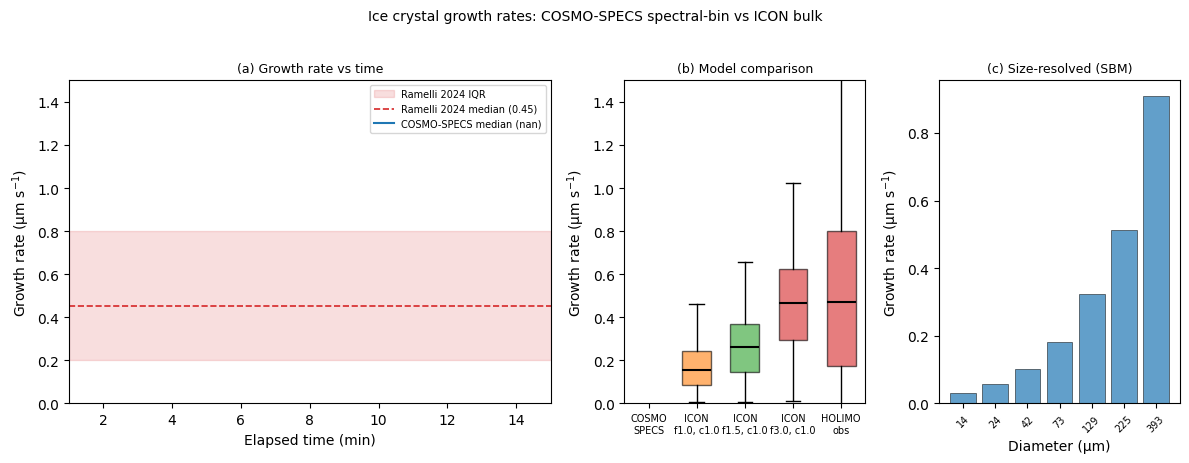

Saved: output/figure_growth_rate_comparison.png


In [7]:
# --- Figure: Growth Rate Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), gridspec_kw={'width_ratios': [2, 1, 1]})

# Panel A: Growth rate vs elapsed time (scatter)
ax = axes[0]
t_mask = (elapsed_mid_all > 1) & (elapsed_mid_all < 15)
sc = ax.scatter(elapsed_mid_all[t_mask], growth_rates_all[t_mask],
                c=growth_rates_all[t_mask], cmap='viridis', s=8, alpha=0.4,
                vmin=0, vmax=1.0, edgecolors='none')
# Ramelli range
ax.axhspan(RAMELLI_GR['p25'], RAMELLI_GR['p75'], alpha=0.15, color='C3',
           label=f"Ramelli 2024 IQR")
ax.axhline(RAMELLI_GR['median'], color='C3', ls='--', lw=1.2,
           label=f"Ramelli 2024 median ({RAMELLI_GR['median']:.2f})")
# COSMO-SPECS median
med_gr = np.nanmedian(growth_rates_all[t_mask])
ax.axhline(med_gr, color='C0', ls='-', lw=1.5,
           label=f"COSMO-SPECS median ({med_gr:.2f})")
ax.set(xlabel='Elapsed time (min)', ylabel='Growth rate (µm s$^{-1}$)',
       xlim=(1, 15), ylim=(0, 1.5))
ax.legend(fontsize=7, loc='upper right')
ax.set_title('(a) Growth rate vs time', fontsize=9)

# Panel B: Box plot comparison (COSMO-SPECS vs Omanovic configurations)
ax = axes[1]
bp_data = [growth_rates_all[t_mask]]
bp_labels = ['COSMO\nSPECS']
bp_colors = ['C0']
for i, (lbl, vals) in enumerate(OMANOVIC_GR.items()):
    # Synthesize approximate distribution from percentiles for visual comparison
    synth = np.random.normal(vals['median'], (vals['p75'] - vals['p25']) / 1.35, size=200)
    synth = synth[synth > 0]
    bp_data.append(synth)
    short_lbl = lbl.split('(')[1].rstrip(')')
    bp_labels.append(f'ICON\n{short_lbl}')
    bp_colors.append(f'C{i+1}')
bp_data.append(np.random.normal(RAMELLI_GR['median'],
               (RAMELLI_GR['p75'] - RAMELLI_GR['p25']) / 1.35, size=200))
bp_labels.append('HOLIMO\nobs')
bp_colors.append('C3')

bplot = ax.boxplot(bp_data, positions=range(len(bp_data)), widths=0.6,
                   patch_artist=True, showfliers=False, medianprops={'color': 'k', 'lw': 1.5})
for patch, color in zip(bplot['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xticks(range(len(bp_labels)))
ax.set_xticklabels(bp_labels, fontsize=7)
ax.set(ylabel='Growth rate (µm s$^{-1}$)', ylim=(0, 1.5))
ax.set_title('(b) Model comparison', fontsize=9)

# Panel C: Growth rate by diameter bin (spectral advantage)
ax = axes[2]
diam_edges = np.logspace(np.log10(10), np.log10(500), 8)
diam_mids = (diam_edges[:-1] + diam_edges[1:]) / 2

# Compute growth rate per diameter range from the time-diameter PSD
gr_by_bin = []
for i_bin in range(len(diameters)):
    nf_bin = nf.isel(diameter=i_bin).transpose('time', 'cell').values  # (time, cell)
    for c in range(ds.sizes['cell']):
        col = nf_bin[:, c]
        peaks = np.where(col > 0)[0]
        if len(peaks) < 2:
            continue
        # Growth rate approximated from concentration-weighted diameter shift
        t_first, t_last = peaks[0], peaks[-1]
        dt_bin = elapsed_s[t_last] - elapsed_s[t_first]
        if dt_bin > 0:
            gr_by_bin.append((diameters[i_bin], diameters[i_bin] / (dt_bin + 1e-10)))

if gr_by_bin:
    gr_arr = np.array(gr_by_bin)
    # Bin the growth rates by diameter
    binned_gr = []
    for lo, hi in zip(diam_edges[:-1], diam_edges[1:]):
        mask_d = (gr_arr[:, 0] >= lo) & (gr_arr[:, 0] < hi)
        if mask_d.sum() > 0:
            binned_gr.append(np.nanmedian(gr_arr[mask_d, 1]))
        else:
            binned_gr.append(np.nan)
    ax.bar(range(len(diam_mids)), binned_gr, color='C0', alpha=0.7, edgecolor='k', lw=0.5)
    ax.set_xticks(range(len(diam_mids)))
    ax.set_xticklabels([f'{d:.0f}' for d in diam_mids], fontsize=7, rotation=45)
    ax.set(xlabel='Diameter (µm)', ylabel='Growth rate (µm s$^{-1}$)')
ax.set_title('(c) Size-resolved (SBM)', fontsize=9)

fig.suptitle('Ice crystal growth rates: COSMO-SPECS spectral-bin vs ICON bulk',
             fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_growth_rate_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_growth_rate_comparison.png'}")